# Calibration diagnostics

Per-session per-cell T_sys distributions. Run `scan_load.ipynb` first
(it writes `scan_load_state.pkl` with `tsys_by_session_cell`).

In [1]:
import pickle
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

STATE_PATH = Path('scan_load_state.pkl')
with open(STATE_PATH, 'rb') as f:
    state = pickle.load(f)

tsys_by_session_cell = state['tsys_by_session_cell']
sessions = state['sessions']
T_CAL = state.get('T_CAL_11', 79.0)

tsys_per_session = defaultdict(list)
for (sess, gl, gb), tsys in tsys_by_session_cell.items():
    tsys_per_session[sess].append(tsys)

all_tsys = np.array([t for ts in tsys_per_session.values() for t in ts])
print(f'Loaded {len(tsys_by_session_cell)} (session, cell) T_sys entries '
      f'across {len(tsys_per_session)} sessions')
print(f'Global: median={np.median(all_tsys):.1f} K, '
      f'range=[{all_tsys.min():.0f}, {all_tsys.max():.0f}] K')

Loaded 965 (session, cell) T_sys entries across 22 sessions
Global: median=133.3 K, range=[103, 188] K


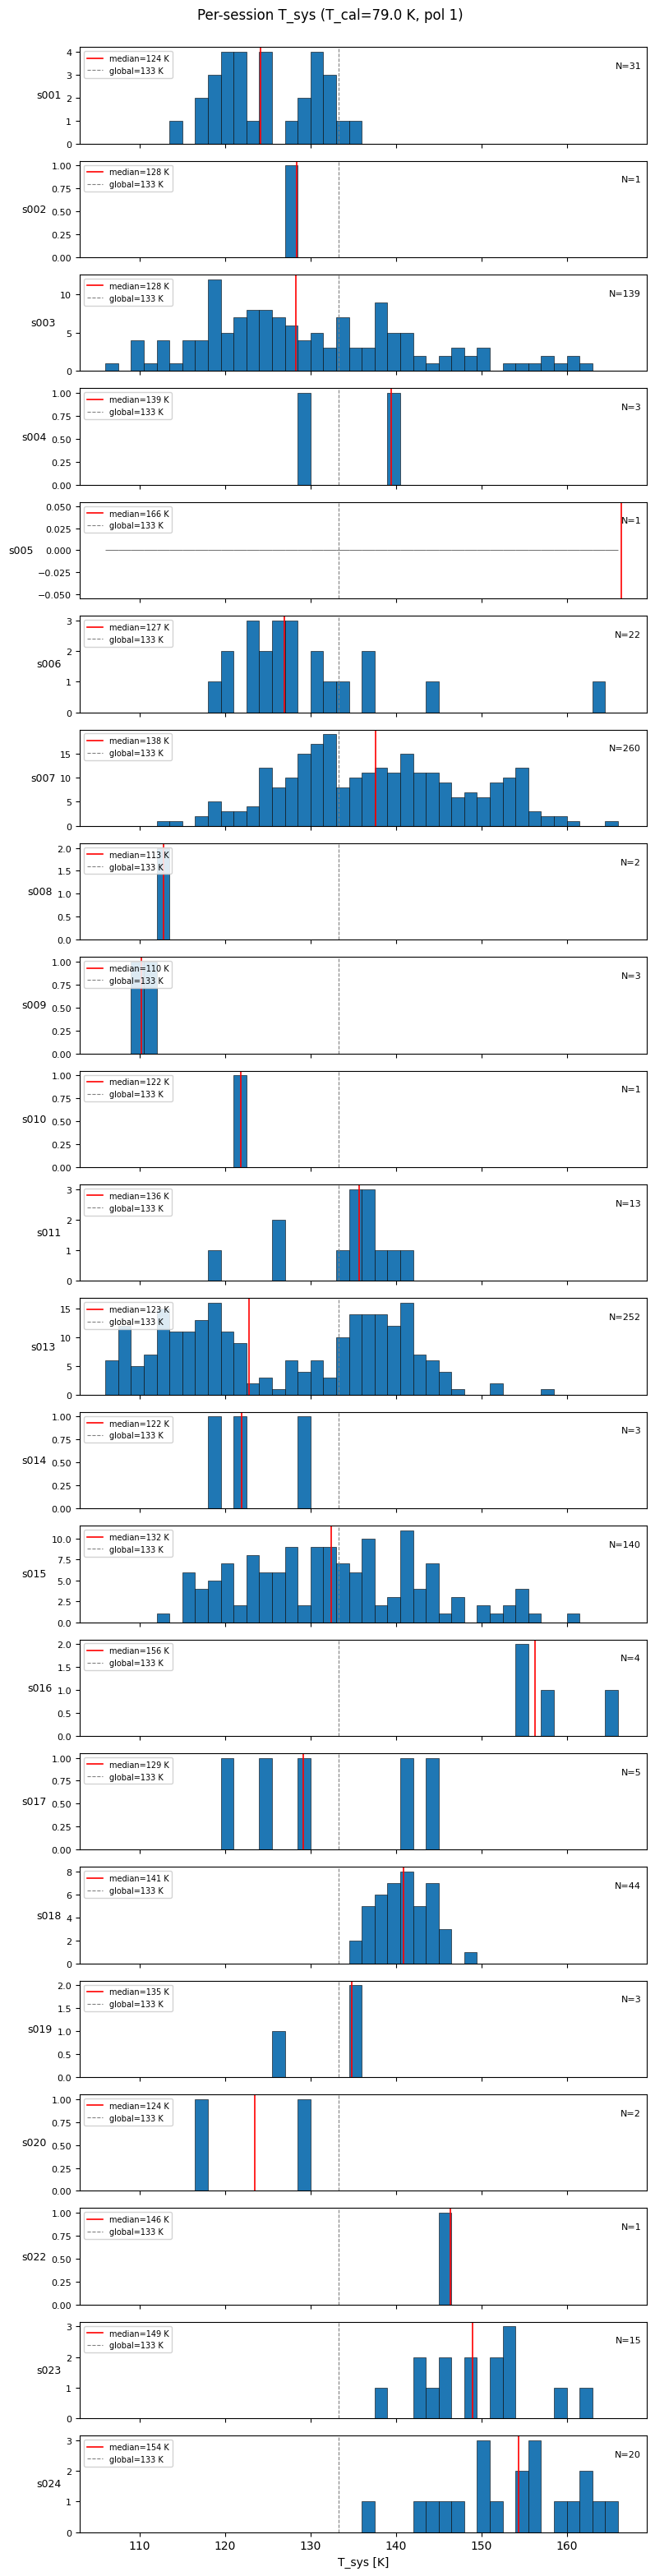

In [2]:
active_sessions = [s for s in sessions if tsys_per_session.get(s)]
n = len(active_sessions)

lo = np.floor(np.percentile(all_tsys, 1))
hi = np.ceil(np.percentile(all_tsys, 99))
bins = np.linspace(lo, hi, 41)
global_med = float(np.median(all_tsys))

fig, axes = plt.subplots(n, 1, figsize=(8, 1.4 * n + 0.5), sharex=True)
if n == 1:
    axes = [axes]

for ax, sess in zip(axes, active_sessions):
    vals = np.array(tsys_per_session[sess])
    ax.hist(vals, bins=bins, color='C0', edgecolor='black', linewidth=0.4)
    med = float(np.median(vals))
    ax.axvline(med, color='red', lw=1.2,
               label=f'median={med:.0f} K')
    ax.axvline(global_med, color='gray', ls='--', lw=0.8,
               label=f'global={global_med:.0f} K')
    ax.set_ylabel(sess.replace('session_', 's'),
                  rotation=0, ha='right', va='center', fontsize=9)
    ax.text(0.99, 0.85, f'N={len(vals)}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8)
    ax.legend(loc='upper left', fontsize=7, framealpha=0.85)
    ax.tick_params(axis='y', labelsize=8)

axes[-1].set_xlabel('T_sys [K]')
fig.suptitle(f'Per-session T_sys (T_cal={T_CAL} K, pol 1)', y=1.0)
plt.tight_layout()
plt.show()